In [21]:
# ==========================================
# SECTION 1: WEB SCRAPING & FEATURE EXTRACTION
# ==========================================
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def extract_url_features(url):
    """
    Live URL mathi BeautifulSoup ane Requests thi features extract karva
    """
    features = {
        'length_url': len(url),
        'qty_dot_url': url.count('.'),
        'qty_hyphen_url': url.count('-'),
        'qty_slash_url': url.count('/'),
        'tls_ssl_certificate': 1 if url.startswith('https://') else 0
    }
    
    try:
        response = requests.get(url, timeout=3)
        features['http_status'] = response.status_code
        soup = BeautifulSoup(response.text, 'html.parser')
        features['has_form'] = 1 if len(soup.find_all('form')) > 0 else 0
    except Exception as e:
        features['http_status'] = 0
        features['has_form'] = 0
        
    return features

# Test Live Web Scraping
test_url = "https://www.google.com"
print("Extracted Features for Live URL:", extract_url_features(test_url))

Extracted Features for Live URL: {'length_url': 22, 'qty_dot_url': 2, 'qty_hyphen_url': 0, 'qty_slash_url': 2, 'tls_ssl_certificate': 1, 'http_status': 200, 'has_form': 1}


In [22]:
# ==========================================
# SECTION 2 & 3: FILE HANDLING & PREPROCESSING
# ==========================================
import os

# Directly target the correct dataset
dataset_path = "phishing_dataset.csv.csv"

if not os.path.exists(dataset_path):
    # Fallback if renamed
    dataset_path = "phishing_dataset.csv"

print(f"Loading Dataset from: {dataset_path}")
df = pd.read_csv(dataset_path)

# Preprocessing: Duplicates and Missing Values
df = df.drop_duplicates()
df = df.fillna(df.median(numeric_only=True))

# Target column identification ('phishing' or 'Result')
target_col = 'phishing' if 'phishing' in df.columns else ('Result' if 'Result' in df.columns else df.columns[-1])
if df[target_col].min() == -1:
    df[target_col] = df[target_col].map({-1: 1, 1: 0})

print("Dataset Shape:", df.shape)
print("Missing Values Count:", df.isnull().sum().sum())
print("Class Distribution:\n", df[target_col].value_counts())

# CRUD Logging function
def log_scan_result(url, prediction_result):
    log_file = "scan_logs.txt"
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with open(log_file, "a") as f:
        f.write(f"[{timestamp}] URL: {url} | Result: {prediction_result}\n")
    print(f"Log saved to {log_file}")

log_scan_result("http://suspicious-phishing-test.com", "Phishing Detected")

Loading Dataset from: phishing_dataset.csv.csv
Dataset Shape: (87209, 112)
Missing Values Count: 0
Class Distribution:
 phishing
0    56712
1    30497
Name: count, dtype: int64
Log saved to scan_logs.txt


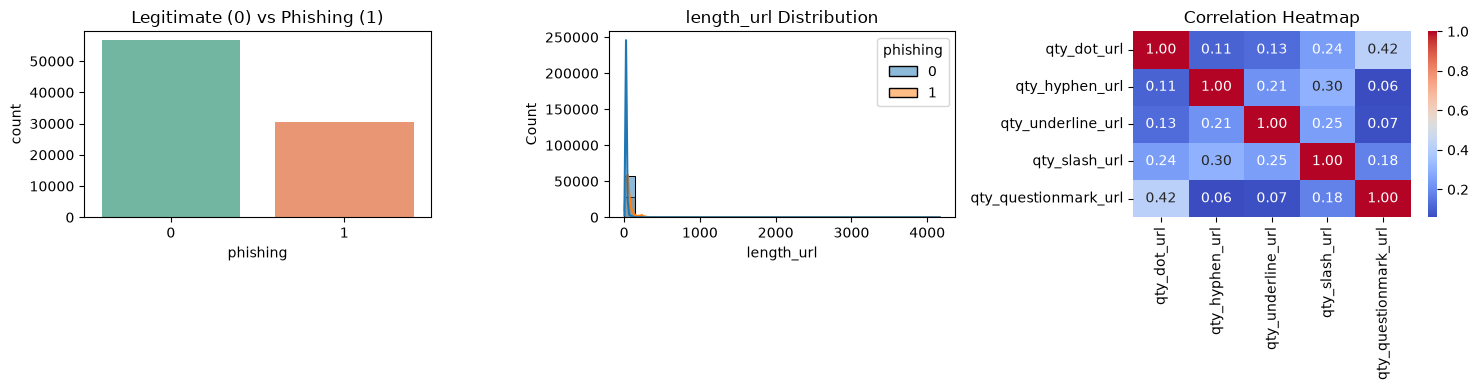

Hypothesis T-Test Statistic: -147.3961, p-value: 0.0
Conclusion: Reject Null Hypothesis. 'length_url' is statistically significant between Phishing and Legitimate URLs.


In [23]:
# ==========================================
# SECTION 4: DATA VISUALIZATION & HYPOTHESIS TESTING
# ==========================================

# Identify URL Length column
length_col = 'length_url' if 'length_url' in df.columns else df.select_dtypes(include=[np.number]).columns[0]

plt.figure(figsize=(15, 4))

# 1. Bar Chart: Legitimate vs Phishing
plt.subplot(1, 3, 1)
sns.countplot(x=target_col, hue=target_col, data=df, palette='Set2', legend=False)
plt.title('Legitimate (0) vs Phishing (1)')

# 2. Histogram: URL Length Distribution
plt.subplot(1, 3, 2)
sns.histplot(data=df, x=length_col, hue=target_col, bins=30, kde=True)
plt.title(f'{length_col} Distribution')

# 3. Correlation Heatmap
plt.subplot(1, 3, 3)
num_cols = df.select_dtypes(include=[np.number]).columns[:5]
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# --- Hypothesis Testing ---
legit_lengths = df[df[target_col] == 0][length_col]
phish_lengths = df[df[target_col] == 1][length_col]

t_stat, p_val = stats.ttest_ind(legit_lengths, phish_lengths, nan_policy='omit')
print(f"Hypothesis T-Test Statistic: {t_stat:.4f}, p-value: {p_val}")

if p_val < 0.05:
    print(f"Conclusion: Reject Null Hypothesis. '{length_col}' is statistically significant between Phishing and Legitimate URLs.")
else:
    print("Conclusion: Fail to Reject Null Hypothesis.")

--- Random Forest Performance ---
Accuracy Score: 96.93%

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     11343
           1       0.96      0.96      0.96      6099

    accuracy                           0.97     17442
   macro avg       0.97      0.97      0.97     17442
weighted avg       0.97      0.97      0.97     17442



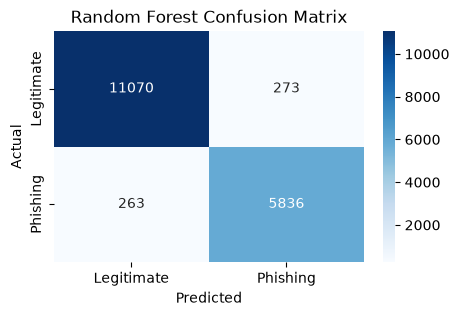

In [25]:
# ==========================================
# SECTION 5: MACHINE LEARNING MODEL TRAINING
# ==========================================

# Feature & Target Separation
X = df.drop(columns=[target_col])
y = df[target_col]

# Encoding non-numeric columns if any exist
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Random Forest Model Training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Model Performance Summary
print("--- Random Forest Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix Plot
plt.figure(figsize=(5, 3))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()